# Chapter 10: Gauss' Theorema Egregium

**Source orientation:** Pressley, *Elementary Differential Geometry*, Chapter 10, printed pp. 247-269; PDF pp. 249-270; sections 10.1-10.4. The PDF span was read for structure, terminology, and theorem flow only. The prose, diagrams, examples, code, and checks below are original course material and do not reproduce textbook text, exercises, screenshots, page crops, or figures.

## Chapter Goal

Gauss' Theorema Egregium says that Gaussian curvature is not merely a measurement of how a surface sits in `R^3`. Once the first fundamental form is known, the Christoffel symbols are known, and the Gauss equations recover `K` from those metric coefficients alone. The notebook turns that claim into executable evidence: compute `K` from `E,F,G`, compare embeddings with the same metric, and keep the proof dependencies visible.

A good mental model for the chapter is this chain:

`first fundamental form -> Christoffel symbols -> Gauss equations -> intrinsic K`.

The second fundamental form remains important, but it enters through compatibility. Two forms cannot be chosen independently; Codazzi-Mainardi and Gauss equations are the consistency tests that say whether the local moving frame could have come from an actual surface patch.

## Computational Translation Guide

| Pressley-side object | Computational object in this notebook | What to inspect |
| --- | --- | --- |
| First fundamental form `E du^2 + 2F du dv + G dv^2` | A `2 x 2` symbolic metric matrix | Which quantities use only `E,F,G` and their derivatives. |
| Christoffel symbols | Arrays `Gamma[k][i][j]` computed from the metric | They record how the coordinate tangent basis changes intrinsically. |
| Gauss equations | Symbolic curvature formula using Christoffel symbols | `K` is recovered without `L,M,N`. |
| Second fundamental form | Symbolic `L,M,N` from explicit embeddings | Different embeddings can bend differently while sharing metric data. |
| Bending without stretching | Plane/cylinder and catenoid/helicoid comparisons | Same first form, changed normal behavior, same intrinsic curvature. |
| Constant curvature models | The geodesic metric `du^2 + g(u)^2 dv^2` and `K=-g''/g` | `g=1`, `cos u`, `cosh u` give `K=0,1,-1`. |
| Sine-Gordon reduction | A checked solution of `theta_uv = sin(theta)` | Negative constant curvature imposes a nonlinear compatibility condition. |
| Geodesic mapping | Central projection from a hemisphere to a plane | Great circles become straight lines, but speed need not be preserved. |

## Route Through The Chapter

The notebook follows the chapter in four passes. First, it treats the first fundamental form as a metric rather than as a collection of coefficients to memorize. The coefficients `E,F,G` decide lengths and angles in the parameter domain, and their derivatives decide how the coordinate basis changes. That basis-change information is exactly what the Christoffel symbols record.

Second, it places the second fundamental form beside the first without making it subordinate to the first. The cylinder and plane share a metric but do not share normal curvature data. The catenoid and helicoid give a richer version of the same lesson: the metric is fixed while the surface is visibly re-embedded. These comparisons keep the warning clear: Theorema Egregium does not say the whole embedding is intrinsic; it says Gaussian curvature is.

Third, it makes the compatibility proof inspectable. The Gauss equations come from comparing mixed partial derivatives and separating tangent components; the Codazzi-Mainardi equations come from the normal component. Once the tangent comparison is rewritten through Christoffel symbols, `K` can be read from the metric alone. The proof-dependency graph is a scaffold for that bookkeeping.

Fourth, it applies the theorem to constant curvature and geodesic maps. In geodesic coordinates, the function multiplying `dv^2` solves a simple curvature ODE. For constant negative curvature, the Chebyshev-net form produces the sine-Gordon equation. Geodesic maps then shift the focus from preserving lengths to preserving unparameterized geodesic paths, which is why central projection can send great circles to straight lines while changing speed.

Two common mistakes are worth avoiding throughout. Do not confuse a flat picture in the parameter plane with a flat surface metric; the metric coefficients decide measured geometry. Also do not confuse a geodesic map with an isometry; a geodesic map can preserve the path family while changing lengths, areas, and preferred parameters.

In [1]:
from pathlib import Path
import sys
import json
import math

import numpy as np
import pandas as pd
import sympy as sp

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import networkx as nx
import plotly.graph_objects as go
from plotly.subplots import make_subplots

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json  # noqa: E402

UNIT = "chapter-10"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
FIGURE_DIR = UNIT_ARTIFACT_ROOT / "figures"
CHECK_DIR = UNIT_ARTIFACT_ROOT / "checks"
TABLE_DIR = UNIT_ARTIFACT_ROOT / "tables"
INTERACTIVE_DIR = UNIT_ARTIFACT_ROOT / "interactive"
for directory in [FIGURE_DIR, CHECK_DIR, TABLE_DIR, INTERACTIVE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 170,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
})

created_artifacts = []

def remember(path):
    path = Path(path)
    created_artifacts.append(path)
    return path

def rel(path):
    return Path(path).relative_to(BOOK_ROOT).as_posix()


## Refreshed Visualization Storyboard

The storyboard is stored as JSON so later chapter workers and QC passes can see why each artifact exists. The sequence is deliberately tied to Chapter 10: metric coefficients, Christoffel symbols, compatibility equations, fixed-metric bending, constant curvature normal forms, and geodesic maps.

In [2]:
def build_visual_storyboard():
    return {
        "chapter_goal": "Recover Gaussian curvature from first fundamental form data and inspect why local isometries preserve it.",
        "source_span_read": {
            "textbook": "Andrew Pressley, Elementary Differential Geometry, Second Edition",
            "printed_pages": "247-269",
            "pdf_pages": "249-270",
            "sections": "10.1-10.4",
            "source_file": "Elementary Differential Geometry (Andrew Pressley).pdf",
            "orientation_notes": [
                "10.1 relates first and second fundamental forms through Codazzi-Mainardi and Gauss equations.",
                "10.2 deduces Theorema Egregium and gives metric-only curvature formulas and isometry obstructions.",
                "10.3 reduces constant curvature patches to plane, sphere, pseudosphere models and the sine-Gordon equation for K=-1.",
                "10.4 studies geodesic maps, including central projection and Beltrami's constant-curvature criterion.",
            ],
        },
        "concept_inventory": [
            "first and second fundamental forms as compatible data",
            "Christoffel symbols as metric-derived connection coefficients",
            "Gaussian curvature from Gauss equations",
            "local isometry and bending without stretching",
            "constant curvature geodesic coordinates",
            "Chebyshev nets and sine-Gordon compatibility for K=-1",
            "geodesic local diffeomorphisms and central projection",
        ],
        "library_routing_table": [
            {"concept": "metric-to-curvature identities", "representation": "exact symbolic tensor calculation", "library": "SymPy", "why": "the theorem is an identity among derivatives of E,F,G and Christoffel symbols"},
            {"concept": "same metric, different embeddings", "representation": "rotatable 3D surface comparison plus static thumbnail", "library": "Plotly + Matplotlib", "why": "surface shape and grid bending are easier to inspect in 3D"},
            {"concept": "proof dependencies", "representation": "directed graph", "library": "NetworkX + Matplotlib", "why": "the chapter proof is a dependency chain from metric data to K"},
            {"concept": "constant curvature and sine-Gordon", "representation": "curvature profile and residual heatmap", "library": "SymPy + Matplotlib", "why": "the ODE/PDE reductions are inspectable as functions and residuals"},
            {"concept": "geodesic mapping", "representation": "3D central projection diagram and speed check", "library": "Matplotlib", "why": "the map sends great-circle arcs to straight lines while changing parameter speed"},
        ],
        "visual_sequence": [
            {"artifact": "figures/christoffel-metric-curvature-fields.png", "concept": "Christoffel-symbol intuition", "inspection_target": "compare sqrt(G), Gamma^2_12, and K for the sphere, pseudosphere metric, and helicoid radial metric", "validation": "symbolic residual K_metric - K_expected is zero"},
            {"artifact": "figures/theorema-egregium-proof-dependencies.png", "concept": "Theorema Egregium proof state", "inspection_target": "follow which assumptions feed Codazzi, Gauss, and the intrinsic K conclusion", "validation": "graph has directed path metric -> Christoffel -> K"},
            {"artifact": "figures/same-metric-embedding-pairs.png", "concept": "bending without stretching", "inspection_target": "same parameter grids bend into different embeddings", "validation": "symbolic first-form matrices match within each pair"},
            {"artifact": "interactive/same-metric-catenoid-helicoid.html", "concept": "fixed metric with changed embedding", "inspection_target": "rotate catenoid and helicoid sharing cosh(u)^2(du^2+dv^2)", "validation": "K is -sech(u)^4 for both"},
            {"artifact": "figures/constant-curvature-models-sine-gordon.png", "concept": "constant curvature normal forms", "inspection_target": "see g(u) for K=0,1,-1 and a sine-Gordon solution in the K=-1 Chebyshev form", "validation": "max |theta_uv - sin(theta)| below tolerance"},
            {"artifact": "figures/geodesic-map-central-projection.png", "concept": "geodesic mapping not preserving speed", "inspection_target": "great-circle arc projects to a straight line with nonconstant speed", "validation": "projected speed samples are unequal"},
        ],
        "computational_checks": [
            "exact metric curvature identities for five metrics",
            "explicit first/second form checks for plane, cylinder, sphere, catenoid, and helicoid",
            "fixed-metric equality checks for plane/cylinder and catenoid/helicoid",
            "sine-Gordon residual check",
            "central projection speed variation check",
            "artifact existence, size, and nonblank image checks",
        ],
    }

storyboard = build_visual_storyboard()
source_span_path = remember(save_json(storyboard["source_span_read"], UNIT, "checks", "source-span.json", root=ARTIFACT_ROOT))
storyboard_path = remember(save_json(storyboard, UNIT, "checks", "visual-storyboard.json", root=ARTIFACT_ROOT))
pd.DataFrame(storyboard["visual_sequence"])


,artifact,concept,inspection_target,validation
0,figures/christoffel-metric-curvature-fields.png,Christoffel-symbol intuition,"compare sqrt(G), Gamma^2_12, and K for the sph...",symbolic residual K_metric - K_expected is zero
1,figures/theorema-egregium-proof-dependencies.png,Theorema Egregium proof state,"follow which assumptions feed Codazzi, Gauss, ...",graph has directed path metric -> Christoffel ...
2,figures/same-metric-embedding-pairs.png,bending without stretching,same parameter grids bend into different embed...,symbolic first-form matrices match within each...
3,interactive/same-metric-catenoid-helicoid.html,fixed metric with changed embedding,rotate catenoid and helicoid sharing cosh(u)^2...,K is -sech(u)^4 for both
4,figures/constant-curvature-models-sine-gordon.png,constant curvature normal forms,"see g(u) for K=0,1,-1 and a sine-Gordon soluti...",max |theta_uv - sin(theta)| below tolerance
5,figures/geodesic-map-central-projection.png,geodesic mapping not preserving speed,great-circle arc projects to a straight line w...,projected speed samples are unequal


## From Metric Coefficients To Intrinsic Curvature

The central computational object is the metric matrix

\[
g=\begin{pmatrix}E&F\\F&G\end{pmatrix}.
\]

From `g` we compute Christoffel symbols by the standard Levi-Civita formula. Then we use Pressley's first Gauss equation in the form

\[
E K=(\Gamma^2_{11})_v-(\Gamma^2_{12})_u+\Gamma^1_{11}\Gamma^2_{12}+\Gamma^2_{11}\Gamma^2_{22}-\Gamma^1_{12}\Gamma^2_{11}-(\Gamma^2_{12})^2.
\]

This is the notebook's executable version of the Egregium mechanism: no second fundamental form appears on the right.

In [3]:
u, v = sp.symbols("u v", real=True)
coords = (u, v)


def christoffel_from_metric(metric, coords):
    metric = sp.Matrix(metric)
    inverse = sp.simplify(metric.inv())
    n = len(coords)
    Gamma = [[[sp.Integer(0) for _ in range(n)] for _ in range(n)] for _ in range(n)]
    for k in range(n):
        for i in range(n):
            for j in range(n):
                expr = sp.Integer(0)
                for ell in range(n):
                    expr += inverse[k, ell] * (
                        sp.diff(metric[j, ell], coords[i])
                        + sp.diff(metric[i, ell], coords[j])
                        - sp.diff(metric[i, j], coords[ell])
                    ) / 2
                Gamma[k][i][j] = sp.simplify(expr)
    return Gamma


def pressley_gauss_K_from_metric(metric, coords):
    metric = sp.Matrix(metric)
    E = metric[0, 0]
    Gamma = christoffel_from_metric(metric, coords)
    G111 = Gamma[0][0][0]
    G211 = Gamma[1][0][0]
    G112 = Gamma[0][0][1]
    G212 = Gamma[1][0][1]
    G222 = Gamma[1][1][1]
    numerator = (
        sp.diff(G211, coords[1])
        - sp.diff(G212, coords[0])
        + G111 * G212
        + G211 * G222
        - G112 * G211
        - G212**2
    )
    return sp.simplify(sp.trigsimp(numerator / E))


def expr_text(expr):
    return str(sp.simplify(sp.trigsimp(expr)))

metric_models = {
    "plane or unwrapped cylinder": {
        "metric": sp.Matrix([[1, 0], [0, 1]]),
        "expected_K": sp.Integer(0),
        "inspect": "all Christoffel symbols vanish",
    },
    "unit sphere latitude metric": {
        "metric": sp.Matrix([[1, 0], [0, sp.cos(u) ** 2]]),
        "expected_K": sp.Integer(1),
        "inspect": "Gamma^2_12=-tan(u) records longitude convergence",
    },
    "pseudosphere geodesic metric": {
        "metric": sp.Matrix([[1, 0], [0, sp.cosh(u) ** 2]]),
        "expected_K": sp.Integer(-1),
        "inspect": "Gamma^2_12=tanh(u) produces constant negative K",
    },
    "helicoid radial metric": {
        "metric": sp.Matrix([[1, 0], [0, 1 + u**2]]),
        "expected_K": -1 / (1 + u**2) ** 2,
        "inspect": "K varies with distance from the axis",
    },
    "catenoid-helicoid associate metric": {
        "metric": sp.Matrix([[sp.cosh(u) ** 2, 0], [0, sp.cosh(u) ** 2]]),
        "expected_K": -1 / sp.cosh(u) ** 4,
        "inspect": "two different embeddings share this conformal metric",
    },
}

identity_rows = []
for name, data in metric_models.items():
    metric = data["metric"]
    Gamma = christoffel_from_metric(metric, coords)
    K_metric = pressley_gauss_K_from_metric(metric, coords)
    residual = sp.simplify(sp.trigsimp(K_metric - data["expected_K"]))
    assert residual == 0
    identity_rows.append({
        "model": name,
        "metric_matrix": str(metric.tolist()),
        "Gamma^2_12": expr_text(Gamma[1][0][1]),
        "K_from_metric": expr_text(K_metric),
        "expected_K": expr_text(data["expected_K"]),
        "residual": expr_text(residual),
        "inspection_note": data["inspect"],
    })

metric_identity_path = remember(save_json({"rows": identity_rows}, UNIT, "checks", "metric-curvature-identities.json", root=ARTIFACT_ROOT))
metric_identity_table = pd.DataFrame(identity_rows)
metric_identity_table


,model,metric_matrix,Gamma^2_12,K_from_metric,expected_K,residual,inspection_note
0,plane or unwrapped cylinder,"[[1, 0], [0, 1]]",0,0,0,0,all Christoffel symbols vanish
1,unit sphere latitude metric,"[[1, 0], [0, cos(u)**2]]",-tan(u),1,1,0,Gamma^2_12=-tan(u) records longitude convergence
2,pseudosphere geodesic metric,"[[1, 0], [0, cosh(u)**2]]",tanh(u),-1,-1,0,Gamma^2_12=tanh(u) produces constant negative K
3,helicoid radial metric,"[[1, 0], [0, u**2 + 1]]",u/(u**2 + 1),-1/(u**2 + 1)**2,-1/(u**2 + 1)**2,0,K varies with distance from the axis
4,catenoid-helicoid associate metric,"[[cosh(u)**2, 0], [0, cosh(u)**2]]",tanh(u),-1/cosh(u)**4,-1/cosh(u)**4,0,two different embeddings share this conformal ...


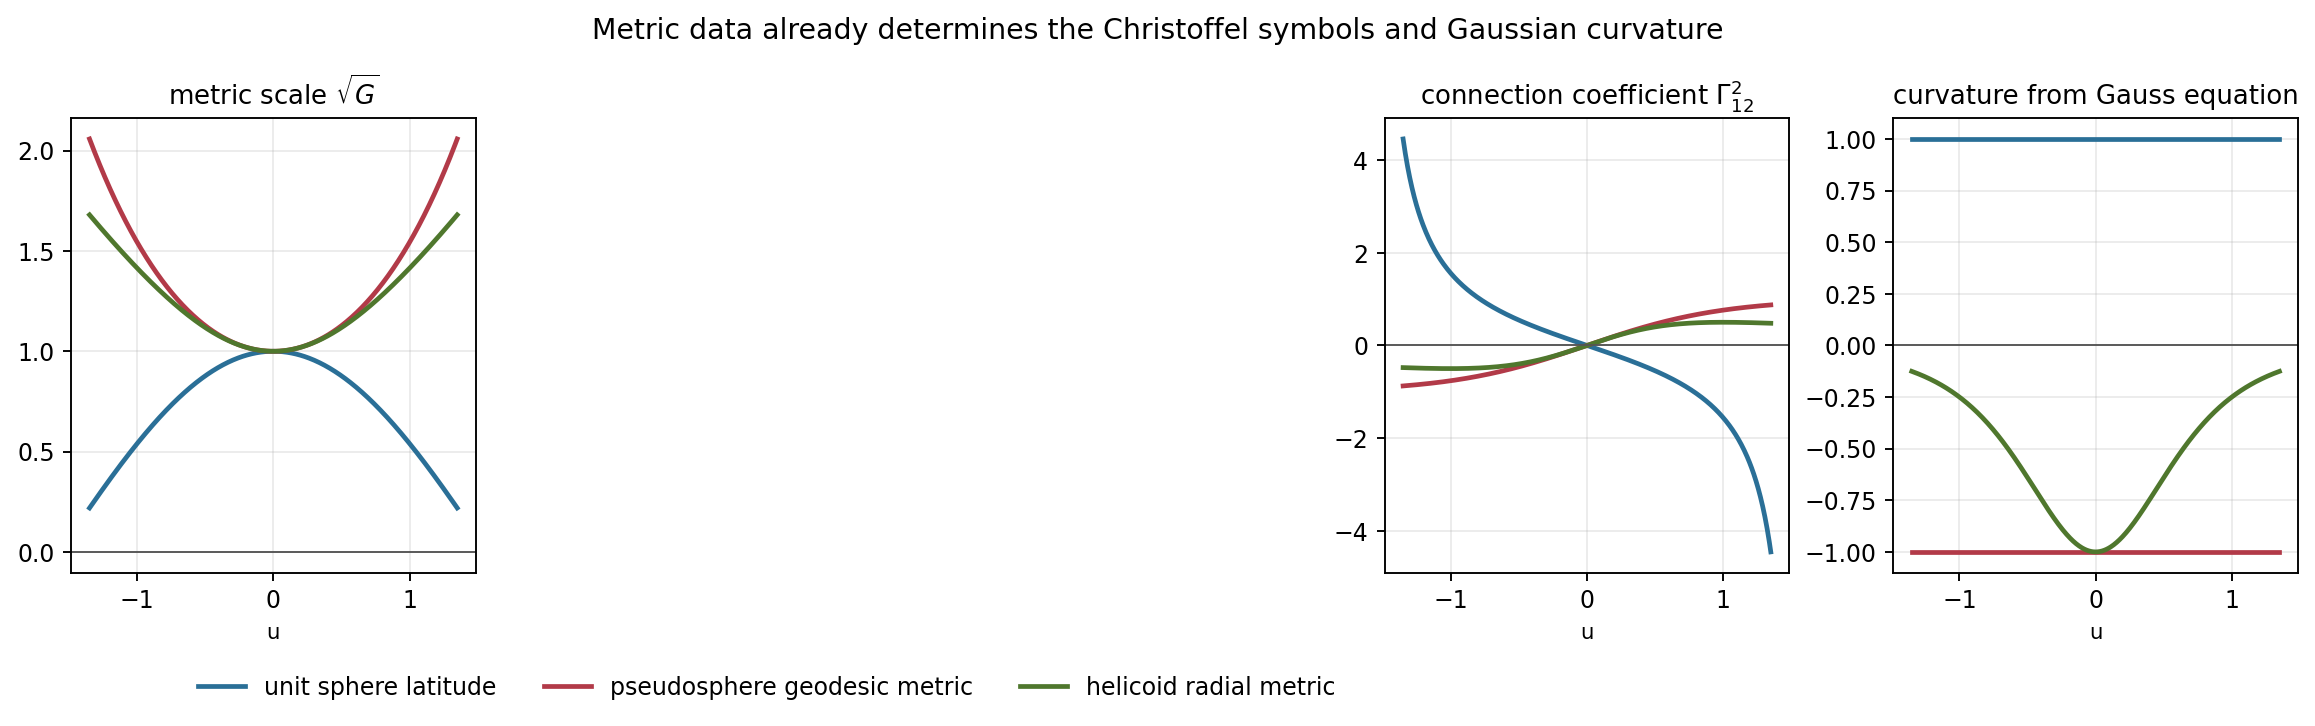

In [4]:
x = np.linspace(-1.35, 1.35, 500)
profiles = [
    {"name": "unit sphere latitude", "sqrt_G": np.cos(x), "Gamma": -np.tan(x), "K": np.ones_like(x), "color": "#2a6f97"},
    {"name": "pseudosphere geodesic metric", "sqrt_G": np.cosh(x), "Gamma": np.tanh(x), "K": -np.ones_like(x), "color": "#b23a48"},
    {"name": "helicoid radial metric", "sqrt_G": np.sqrt(1 + x**2), "Gamma": x / (1 + x**2), "K": -1 / (1 + x**2) ** 2, "color": "#4f772d"},
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
for profile in profiles:
    axes[0].plot(x, profile["sqrt_G"], label=profile["name"], color=profile["color"], linewidth=2)
    axes[1].plot(x, profile["Gamma"], color=profile["color"], linewidth=2)
    axes[2].plot(x, profile["K"], color=profile["color"], linewidth=2)
axes[0].set_title("metric scale $\\sqrt{G}$")
axes[1].set_title("connection coefficient $\\Gamma^2_{12}$")
axes[2].set_title("curvature from Gauss equation")
for ax in axes:
    ax.axhline(0, color="#555555", linewidth=0.8)
    ax.set_xlabel("u")
    ax.grid(alpha=0.25)
axes[0].legend(loc="upper center", bbox_to_anchor=(1.72, -0.18), ncol=3, frameon=False)
fig.suptitle("Metric data already determines the Christoffel symbols and Gaussian curvature", y=1.08)
christoffel_path = remember(FIGURE_DIR / "christoffel-metric-curvature-fields.png")
fig.savefig(christoffel_path, bbox_inches="tight")
plt.close(fig)
assert_artifact(christoffel_path, min_bytes=1000)
display_artifact(christoffel_path, width=940)


## Compatibility Equations As Proof State

The Gauss and Codazzi-Mainardi equations do not say that the second fundamental form is determined by the first. The plane and cylinder already show that cannot be true. Instead they say the two forms must be compatible with the same moving frame. The proof dependency graph below separates three roles:

- metric data determines `Gamma`, hence the intrinsic side of `K`;
- second-form data enters the normal component and the extrinsic formula `(LN-M^2)/(EG-F^2)`;
- equality of mixed partials forces both sets of compatibility equations.

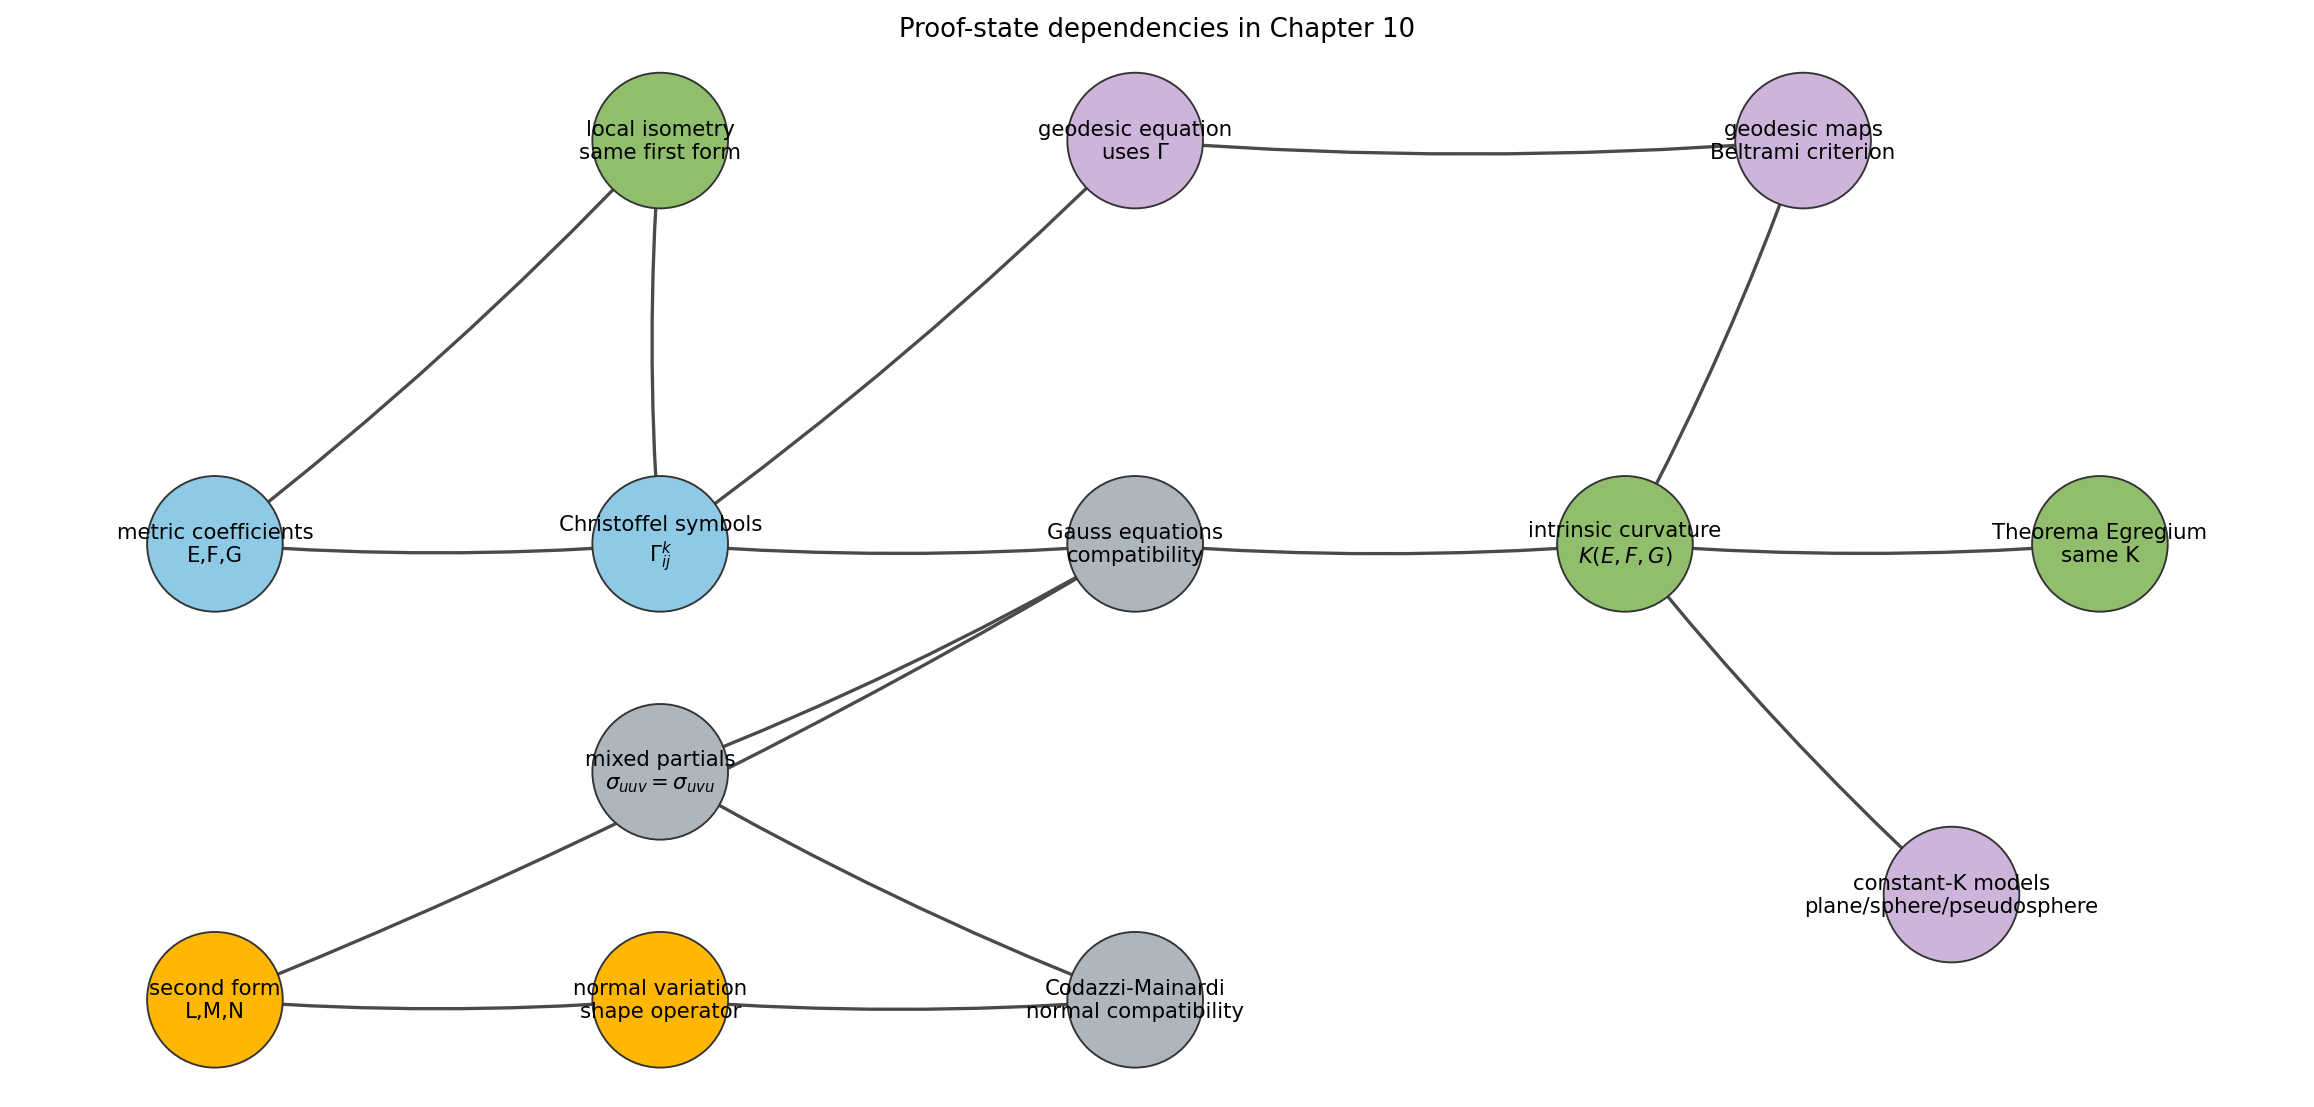

{'node_count': 13,
 'edge_count': 15,
 'has_metric_to_K_path': True,
 'has_second_form_to_codazzi_path': True,
 'has_gamma_to_geodesic_maps_path': True}

In [5]:
G_graph = nx.DiGraph()
node_data = {
    "metric": ("metric coefficients\nE,F,G", "metric"),
    "gamma": ("Christoffel symbols\n$\\Gamma^k_{ij}$", "metric"),
    "gauss_eq": ("Gauss equations\ncompatibility", "compat"),
    "intrinsic_k": ("intrinsic curvature\n$K(E,F,G)$", "result"),
    "second_form": ("second form\nL,M,N", "extrinsic"),
    "shape": ("normal variation\nshape operator", "extrinsic"),
    "codazzi": ("Codazzi-Mainardi\nnormal compatibility", "compat"),
    "mixed": ("mixed partials\n$\\sigma_{uuv}=\\sigma_{uvu}$", "compat"),
    "local_iso": ("local isometry\nsame first form", "result"),
    "egregium": ("Theorema Egregium\nsame K", "result"),
    "constant_k": ("constant-K models\nplane/sphere/pseudosphere", "application"),
    "geodesic_eq": ("geodesic equation\nuses $\\Gamma$", "application"),
    "geodesic_maps": ("geodesic maps\nBeltrami criterion", "application"),
}
for key, (label, group) in node_data.items():
    G_graph.add_node(key, label=label, group=group)
G_graph.add_edges_from([
    ("metric", "gamma"), ("gamma", "gauss_eq"), ("mixed", "gauss_eq"), ("mixed", "codazzi"),
    ("second_form", "shape"), ("shape", "codazzi"), ("second_form", "gauss_eq"),
    ("gauss_eq", "intrinsic_k"), ("metric", "local_iso"), ("local_iso", "gamma"),
    ("intrinsic_k", "egregium"), ("intrinsic_k", "constant_k"), ("gamma", "geodesic_eq"),
    ("geodesic_eq", "geodesic_maps"), ("intrinsic_k", "geodesic_maps"),
])
positions = {
    "metric": (0, 2.2), "gamma": (1.5, 2.2), "gauss_eq": (3.1, 2.2),
    "intrinsic_k": (4.75, 2.2), "egregium": (6.35, 2.2), "local_iso": (1.5, 3.35),
    "second_form": (0, 0.9), "shape": (1.5, 0.9), "codazzi": (3.1, 0.9), "mixed": (1.5, 1.55),
    "constant_k": (5.85, 1.2), "geodesic_eq": (3.1, 3.35), "geodesic_maps": (5.35, 3.35),
}
colors = {"metric": "#8ecae6", "extrinsic": "#ffb703", "compat": "#adb5bd", "result": "#90be6d", "application": "#cdb4db"}
fig, ax = plt.subplots(figsize=(13.5, 6.4), constrained_layout=True)
node_colors = [colors[G_graph.nodes[n]["group"]] for n in G_graph.nodes]
nx.draw_networkx_edges(G_graph, positions, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.4, edge_color="#4a4a4a", connectionstyle="arc3,rad=0.04")
nx.draw_networkx_nodes(G_graph, positions, ax=ax, node_color=node_colors, node_size=3300, edgecolors="#333333", linewidths=0.8)
nx.draw_networkx_labels(G_graph, positions, labels={n: G_graph.nodes[n]["label"] for n in G_graph.nodes}, ax=ax, font_size=9)
ax.set_title("Proof-state dependencies in Chapter 10")
ax.set_axis_off()
proof_path = remember(FIGURE_DIR / "theorema-egregium-proof-dependencies.png")
fig.savefig(proof_path, bbox_inches="tight")
plt.close(fig)
proof_checks = {
    "node_count": G_graph.number_of_nodes(),
    "edge_count": G_graph.number_of_edges(),
    "has_metric_to_K_path": nx.has_path(G_graph, "metric", "intrinsic_k"),
    "has_second_form_to_codazzi_path": nx.has_path(G_graph, "second_form", "codazzi"),
    "has_gamma_to_geodesic_maps_path": nx.has_path(G_graph, "gamma", "geodesic_maps"),
}
assert proof_checks["has_metric_to_K_path"]
assert proof_checks["has_second_form_to_codazzi_path"]
proof_graph_path = remember(save_json(proof_checks, UNIT, "checks", "proof-dependency-graph.json", root=ARTIFACT_ROOT))
display_artifact(proof_path, width=940)
proof_checks


## Same Metric, Different Embedding

Bending without stretching is easiest to see by holding the first fundamental form fixed and changing the embedding.

- The plane patch `(u,v,0)` and the unit cylinder `(cos u, sin u, v)` both have first form `du^2+dv^2`; the second form changes, but `K=0` for both.
- The catenoid `(cosh u cos v, cosh u sin v, u)` and helicoid `(sinh u cos v, sinh u sin v, v)` both have first form `cosh^2(u)(du^2+dv^2)`; their second forms are different, but their Gaussian curvature is the same function `-sech^4(u)`.

The static figure gives a durable notebook view. The standalone rotatable comparison is saved at [same-metric-catenoid-helicoid.html](../artifacts/chapter-10/interactive/same-metric-catenoid-helicoid.html).

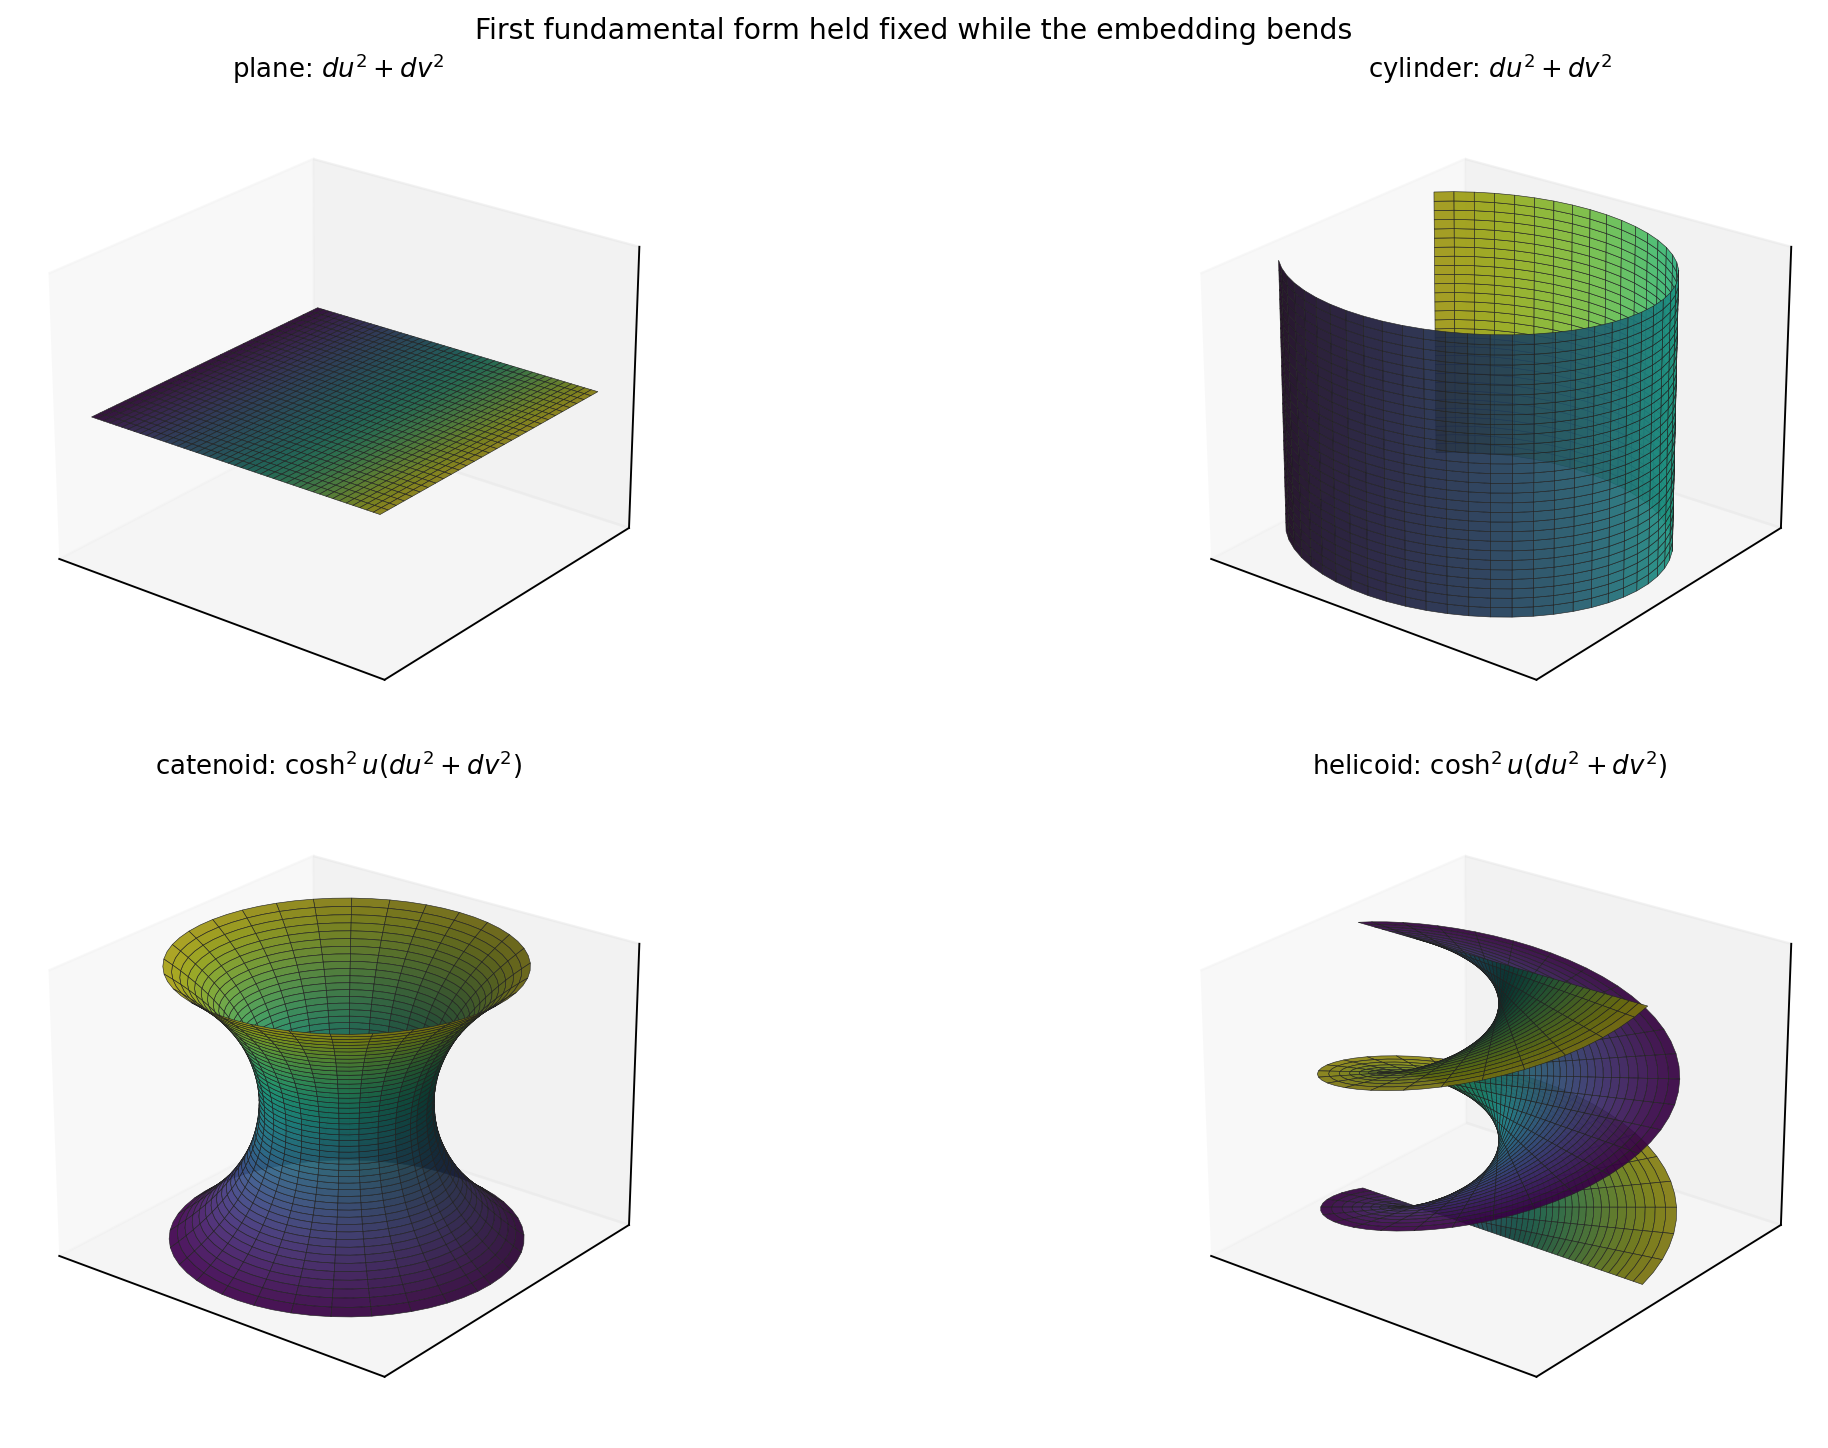

{'static': 'artifacts/chapter-10/figures/same-metric-embedding-pairs.png',
 'interactive': 'artifacts/chapter-10/interactive/same-metric-catenoid-helicoid.html',
 'plane_cylinder_first_form_equal': True,
 'catenoid_helicoid_first_form_equal': True,
 'plane_cylinder_metric': '[[1, 0], [0, 1]]',
 'catenoid_helicoid_metric': '[[cosh(u)**2, 0], [0, cosh(u)**2]]'}

In [6]:
def first_form_from_patch(patch):
    r = sp.Matrix(patch)
    ru = r.diff(u)
    rv = r.diff(v)
    return sp.Matrix([[sp.simplify(ru.dot(ru)), sp.simplify(ru.dot(rv))], [sp.simplify(ru.dot(rv)), sp.simplify(rv.dot(rv))]])

patches_for_metric_compare = {
    "plane": sp.Matrix([u, v, 0]),
    "cylinder": sp.Matrix([sp.cos(u), sp.sin(u), v]),
    "catenoid": sp.Matrix([sp.cosh(u) * sp.cos(v), sp.cosh(u) * sp.sin(v), u]),
    "helicoid": sp.Matrix([sp.sinh(u) * sp.cos(v), sp.sinh(u) * sp.sin(v), v]),
}
first_forms = {name: first_form_from_patch(patch) for name, patch in patches_for_metric_compare.items()}
metric_compare_checks = {
    "plane_cylinder_first_form_equal": first_forms["plane"] == first_forms["cylinder"],
    "catenoid_helicoid_first_form_equal": first_forms["catenoid"] == first_forms["helicoid"],
    "plane_cylinder_metric": str(first_forms["plane"].tolist()),
    "catenoid_helicoid_metric": str(first_forms["catenoid"].tolist()),
}
assert metric_compare_checks["plane_cylinder_first_form_equal"]
assert metric_compare_checks["catenoid_helicoid_first_form_equal"]

fig = plt.figure(figsize=(13.5, 8.2), constrained_layout=True)
axs = [fig.add_subplot(2, 2, i + 1, projection="3d") for i in range(4)]
U1, V1 = np.meshgrid(np.linspace(-2.4, 2.4, 46), np.linspace(-1.4, 1.4, 30), indexing="ij")
plane_xyz = (U1, V1, np.zeros_like(U1))
cyl_xyz = (np.cos(U1), np.sin(U1), V1)
U2, V2 = np.meshgrid(np.linspace(-1.35, 1.35, 50), np.linspace(0, 2 * np.pi, 58), indexing="ij")
cat_xyz = (np.cosh(U2) * np.cos(V2), np.cosh(U2) * np.sin(V2), U2)
hel_xyz = (np.sinh(U2) * np.cos(V2), np.sinh(U2) * np.sin(V2), V2 / np.pi - 1)
surfaces = [
    ("plane: $du^2+dv^2$", plane_xyz, U1),
    ("cylinder: $du^2+dv^2$", cyl_xyz, U1),
    ("catenoid: $\\cosh^2u(du^2+dv^2)$", cat_xyz, U2),
    ("helicoid: $\\cosh^2u(du^2+dv^2)$", hel_xyz, U2),
]
for ax, (title, xyz, colorscale_values) in zip(axs, surfaces):
    X, Y, Z = xyz
    normalized = (colorscale_values - colorscale_values.min()) / (colorscale_values.max() - colorscale_values.min() + 1e-9)
    ax.plot_surface(X, Y, Z, facecolors=cm.viridis(normalized), linewidth=0.25, edgecolor="#222222", alpha=0.92, antialiased=True)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.view_init(elev=24, azim=-52)
fig.suptitle("First fundamental form held fixed while the embedding bends", y=1.02)
same_metric_png = remember(FIGURE_DIR / "same-metric-embedding-pairs.png")
fig.savefig(same_metric_png, bbox_inches="tight")
plt.close(fig)

plotly_fig = make_subplots(rows=1, cols=2, specs=[[{"type": "surface"}, {"type": "surface"}]], subplot_titles=("Catenoid", "Helicoid"), horizontal_spacing=0.02)
plotly_fig.add_trace(go.Surface(x=cat_xyz[0], y=cat_xyz[1], z=cat_xyz[2], surfacecolor=U2, colorscale="Viridis", showscale=False, name="catenoid"), row=1, col=1)
plotly_fig.add_trace(go.Surface(x=hel_xyz[0], y=hel_xyz[1], z=hel_xyz[2], surfacecolor=U2, colorscale="Viridis", showscale=False, name="helicoid"), row=1, col=2)
plotly_fig.update_layout(title="Catenoid and helicoid with shared metric cosh(u)^2(du^2+dv^2)", height=620, margin=dict(l=0, r=0, b=0, t=60))
for scene_name in ["scene", "scene2"]:
    plotly_fig.update_layout({scene_name: dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z")})
same_metric_html = remember(INTERACTIVE_DIR / "same-metric-catenoid-helicoid.html")
plotly_fig.write_html(same_metric_html, include_plotlyjs=True, full_html=True)
metric_compare_path = remember(save_json(metric_compare_checks, UNIT, "checks", "same-metric-embedding-checks.json", root=ARTIFACT_ROOT))
display_artifact(same_metric_png, width=940)
{"static": rel(same_metric_png), "interactive": rel(same_metric_html), **metric_compare_checks}


## Explicit First And Second Fundamental Form Checks

The theorem is intrinsic, but Chapter 10 still depends on seeing both forms at once. The table below computes `E,F,G,L,M,N` from explicit patches and compares extrinsic curvature `(LN-M^2)/(EG-F^2)` with the metric-only curvature from the Gauss equation. A normal reversal may flip `L,M,N`; it cannot change `K`.

In [7]:
def clean_sphere_abs(expr):
    return sp.simplify(sp.trigsimp(expr.subs(sp.Abs(sp.cos(u)), sp.cos(u))))


def is_symbolic_zero(expr):
    simplified = sp.simplify(sp.trigsimp(expr))
    if simplified == 0:
        return True
    return sp.simplify(sp.trigsimp(simplified.rewrite(sp.exp))) == 0


def fundamental_forms_from_patch(patch):
    r = sp.Matrix(patch)
    ru = r.diff(u)
    rv = r.diff(v)
    ruu = r.diff(u, 2)
    ruv = r.diff(u, v)
    rvv = r.diff(v, 2)
    cross = ru.cross(rv)
    normal = cross / sp.sqrt(sp.simplify(cross.dot(cross)))
    E = clean_sphere_abs(ru.dot(ru))
    F = clean_sphere_abs(ru.dot(rv))
    Gcoef = clean_sphere_abs(rv.dot(rv))
    L = clean_sphere_abs(ruu.dot(normal))
    Mcoef = clean_sphere_abs(ruv.dot(normal))
    Ncoef = clean_sphere_abs(rvv.dot(normal))
    K_extrinsic = clean_sphere_abs((L * Ncoef - Mcoef**2) / (E * Gcoef - F**2))
    K_intrinsic = clean_sphere_abs(pressley_gauss_K_from_metric(sp.Matrix([[E, F], [F, Gcoef]]), coords))
    return E, F, Gcoef, L, Mcoef, Ncoef, K_extrinsic, K_intrinsic

explicit_patches = {
    "plane": sp.Matrix([u, v, 0]),
    "unit cylinder": sp.Matrix([sp.cos(u), sp.sin(u), v]),
    "unit sphere latitude patch": sp.Matrix([sp.cos(u) * sp.cos(v), sp.cos(u) * sp.sin(v), sp.sin(u)]),
    "catenoid": patches_for_metric_compare["catenoid"],
    "helicoid": patches_for_metric_compare["helicoid"],
}
form_rows = []
for name, patch in explicit_patches.items():
    E, F, Gcoef, L, Mcoef, Ncoef, K_ext, K_int = fundamental_forms_from_patch(patch)
    residual = sp.simplify(sp.trigsimp(K_ext - K_int))
    assert is_symbolic_zero(residual)
    residual_text = "0" if is_symbolic_zero(residual) else expr_text(residual)
    form_rows.append({
        "patch": name,
        "I: E,F,G": f"({expr_text(E)}, {expr_text(F)}, {expr_text(Gcoef)})",
        "II: L,M,N": f"({expr_text(L)}, {expr_text(Mcoef)}, {expr_text(Ncoef)})",
        "K_extrinsic": expr_text(K_ext),
        "K_from_metric": expr_text(K_int),
        "residual": residual_text,
    })
forms_path = remember(save_json({"rows": form_rows, "note": "sphere latitude patch uses |u|<pi/2 so cos(u)>0"}, UNIT, "checks", "surface-form-curvature-checks.json", root=ARTIFACT_ROOT))
forms_table = pd.DataFrame(form_rows)
forms_table


,patch,"I: E,F,G","II: L,M,N",K_extrinsic,K_from_metric,residual
0,plane,"(1, 0, 1)","(0, 0, 0)",0,0,0
1,unit cylinder,"(1, 0, 1)","(-1, 0, 0)",0,0,0
2,unit sphere latitude patch,"(1, 0, cos(u)**2)","(sin(2*u)*tan(u)/2 + cos(2*u)/2 + 1/2, 0, cos(...",sin(2*u)*tan(u)/2 + cos(2*u)/2 + 1/2,1,0
3,catenoid,"(cosh(u)**2, 0, cosh(u)**2)","(-1, 0, 1)",-1/cosh(u)**4,-1/cosh(u)**4,0
4,helicoid,"(cosh(u)**2, 0, cosh(u)**2)","(0, -1, 0)",-1/cosh(u)**4,-1/cosh(u)**4,0


## Constant Curvature Normal Forms And Sine-Gordon

In geodesic coordinates with first form `du^2 + g(u,v)^2 dv^2`, constant curvature reduces locally to

\[
g_{uu}+K g=0,
\]

with the initial conditions coming from the geodesic patch. This gives the familiar local models `g=1`, `g=cos u`, and `g=cosh u` for `K=0,1,-1`.

For constant negative curvature, a sharper asymptotic-line description uses a Chebyshev net. The first and second forms have the shape

\[
du^2+2\cos\theta\,du\,dv+dv^2,\qquad 2\sin\theta\,du\,dv,
\]

and compatibility reduces to the sine-Gordon equation `theta_uv = sin(theta)`. The figure checks one exact solution on a domain where `0<theta<pi`.

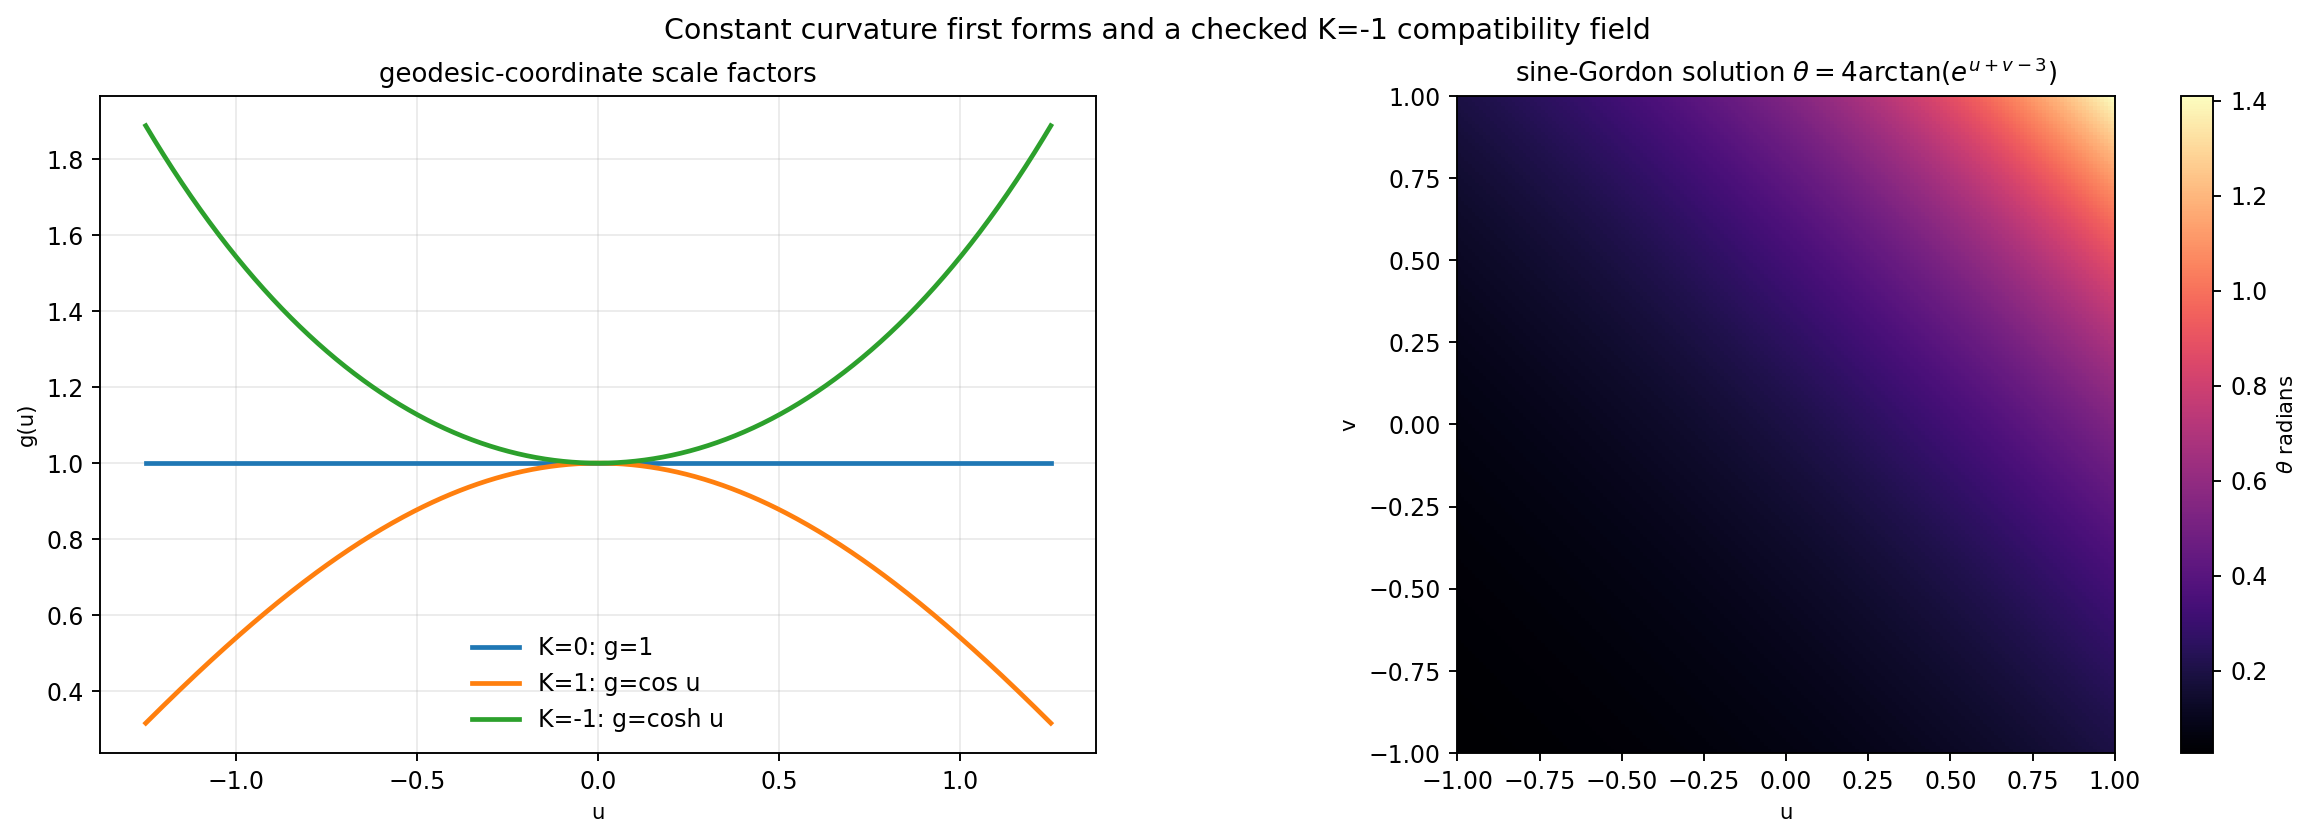

{'max_abs_sine_gordon_residual': 0.0,
 'theta_range': [0.026951380137691192, 1.410053687110476]}

In [8]:
uu = np.linspace(-1.25, 1.25, 500)
g_profiles = {
    "K=0: g=1": np.ones_like(uu),
    "K=1: g=cos u": np.cos(uu),
    "K=-1: g=cosh u": np.cosh(uu),
}
Usg, Vsg = np.meshgrid(np.linspace(-1.0, 1.0, 180), np.linspace(-1.0, 1.0, 180), indexing="ij")
Ssg = Usg + Vsg - 3.0
theta_values = 4 * np.arctan(np.exp(Ssg))
theta = 4 * sp.atan(sp.exp(u + v - 3))
sine_gordon_residual = sp.simplify(sp.diff(theta, u, v) - sp.sin(theta))
assert sine_gordon_residual == 0
residual_fn = sp.lambdify((u, v), sine_gordon_residual, "numpy")
residual_values = np.zeros_like(theta_values, dtype=float) + residual_fn(Usg, Vsg)
max_sine_residual = float(np.nanmax(np.abs(residual_values)))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), constrained_layout=True)
for label, values in g_profiles.items():
    axes[0].plot(uu, values, linewidth=2, label=label)
axes[0].set_title("geodesic-coordinate scale factors")
axes[0].set_xlabel("u")
axes[0].set_ylabel("g(u)")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)
image = axes[1].imshow(theta_values.T, extent=[Usg.min(), Usg.max(), Vsg.min(), Vsg.max()], origin="lower", cmap="magma", aspect="equal")
axes[1].set_title(r"sine-Gordon solution $\theta=4\arctan(e^{u+v-3})$")
axes[1].set_xlabel("u")
axes[1].set_ylabel("v")
cbar = fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label(r"$\theta$ radians")
fig.suptitle("Constant curvature first forms and a checked K=-1 compatibility field", y=1.04)
constant_path = remember(FIGURE_DIR / "constant-curvature-models-sine-gordon.png")
fig.savefig(constant_path, bbox_inches="tight")
plt.close(fig)
sine_path = remember(save_json({
    "theta": "4*atan(exp(u+v-3))",
    "domain": {"u": [-1.0, 1.0], "v": [-1.0, 1.0]},
    "theta_range_numeric": [float(theta_values.min()), float(theta_values.max())],
    "symbolic_residual": str(sine_gordon_residual),
    "max_abs_numeric_residual": max_sine_residual,
    "passes": max_sine_residual < 1e-12,
}, UNIT, "checks", "sine-gordon-check.json", root=ARTIFACT_ROOT))
assert max_sine_residual < 1e-12
assert 0 < float(theta_values.min()) < float(theta_values.max()) < math.pi
display_artifact(constant_path, width=940)
{"max_abs_sine_gordon_residual": max_sine_residual, "theta_range": [float(theta_values.min()), float(theta_values.max())]}


## Geodesic Mapping: Straight Lines Without Preserved Speed

A local isometry preserves geodesics with their arclength parameter, but Chapter 10 broadens the question to maps that preserve geodesics only up to reparametrization. Central projection from the lower unit hemisphere to the plane `z=-1` is the clean model.

A great circle in the `xz`-plane can be written as `gamma(t)=(cos t,0,sin t)` on the lower hemisphere. Projection from the origin to `z=-1` gives `(-cot t,0,-1)`: a straight line in the target plane. Its speed is `csc^2(t)`, so the map sends this geodesic to a pre-geodesic, not to a unit-speed geodesic.

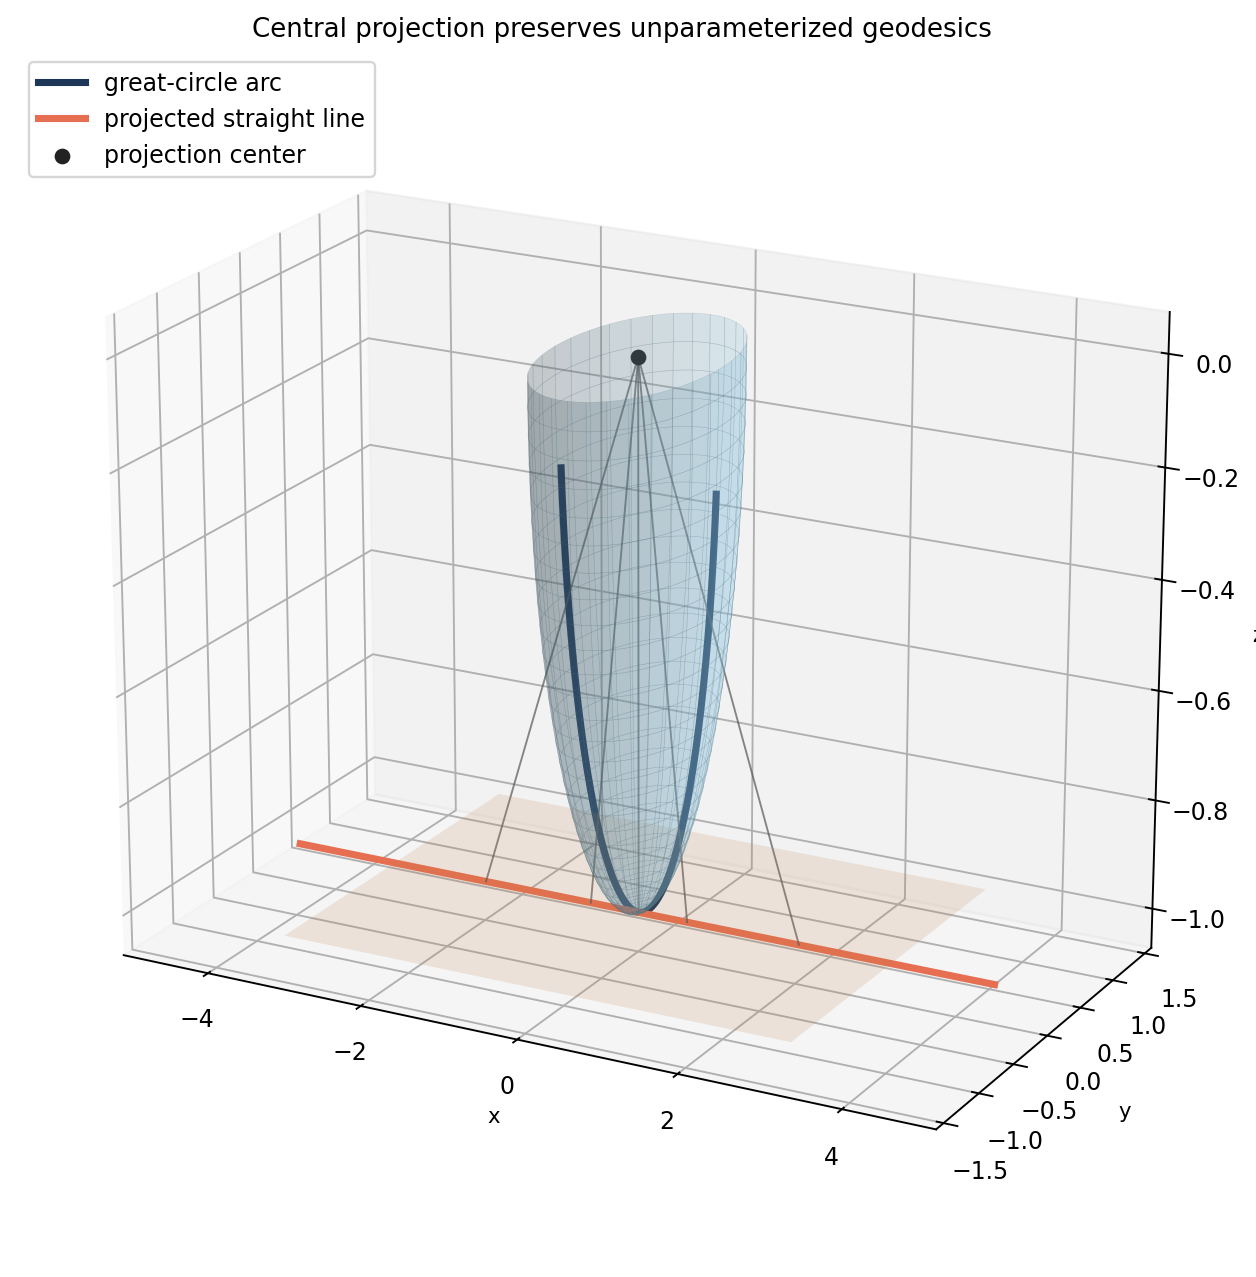

{'projected_curve': '(-cot(t), 0, -1)',
 'projected_speed': 'csc(t)^2',
 'sample_t': [4.1887902047863905, 4.71238898038469, 5.235987755982989],
 'sample_speeds': [1.333333333333334, 1.0, 1.3333333333333335],
 'speed_is_constant_on_samples': False,
 'geodesic_as_unparameterized_line': True}

In [9]:
phi = np.linspace(0, 2 * np.pi, 64)
psi = np.linspace(np.pi / 2, np.pi, 32)
Phi, Psi = np.meshgrid(phi, psi)
Xs = np.sin(Psi) * np.cos(Phi)
Ys = np.sin(Psi) * np.sin(Phi)
Zs = np.cos(Psi)
t = np.linspace(np.pi + 0.22, 2 * np.pi - 0.22, 220)
great = np.vstack([np.cos(t), np.zeros_like(t), np.sin(t)])
projected = np.vstack([-great[0] / great[2], -great[1] / great[2], -np.ones_like(t)])
ray_indices = np.linspace(20, len(t) - 20, 5, dtype=int)

fig = plt.figure(figsize=(9.8, 7.4), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Xs, Ys, Zs, alpha=0.24, color="#8ecae6", edgecolor="#4f6d7a", linewidth=0.2)
plane_x, plane_y = np.meshgrid(np.linspace(-3.2, 3.2, 2), np.linspace(-1.4, 1.4, 2))
plane_z = -np.ones_like(plane_x)
ax.plot_surface(plane_x, plane_y, plane_z, alpha=0.16, color="#f4a261")
ax.plot(great[0], great[1], great[2], color="#1d3557", linewidth=3, label="great-circle arc")
ax.plot(projected[0], projected[1], projected[2], color="#e76f51", linewidth=3, label="projected straight line")
for idx in ray_indices:
    ax.plot([0, great[0, idx], projected[0, idx]], [0, great[1, idx], projected[1, idx]], [0, great[2, idx], projected[2, idx]], color="#555555", linewidth=0.8, alpha=0.7)
ax.scatter([0], [0], [0], color="#222222", s=32, label="projection center")
ax.set_title("Central projection preserves unparameterized geodesics")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.view_init(elev=20, azim=-62)
ax.legend(loc="upper left")
ax.set_box_aspect((1.35, 0.75, 1.0))
geodesic_map_path = remember(FIGURE_DIR / "geodesic-map-central-projection.png")
fig.savefig(geodesic_map_path, bbox_inches="tight")
plt.close(fig)
speed_samples_t = np.array([4 * np.pi / 3, 3 * np.pi / 2, 5 * np.pi / 3])
speed_samples = 1 / np.sin(speed_samples_t) ** 2
geodesic_map_checks = {
    "projected_curve": "(-cot(t), 0, -1)",
    "projected_speed": "csc(t)^2",
    "sample_t": [float(x) for x in speed_samples_t],
    "sample_speeds": [float(x) for x in speed_samples],
    "speed_is_constant_on_samples": bool(np.allclose(speed_samples, speed_samples[0])),
    "geodesic_as_unparameterized_line": True,
}
assert not geodesic_map_checks["speed_is_constant_on_samples"]
geodesic_map_check_path = remember(save_json(geodesic_map_checks, UNIT, "checks", "geodesic-map-central-projection.json", root=ARTIFACT_ROOT))
display_artifact(geodesic_map_path, width=820)
geodesic_map_checks


## Applied Lab: Change The Metric, Not Just The Picture

The quickest way to use this notebook as a lab is to change `u0` below. The catenoid and helicoid rows should continue to agree because their first fundamental forms agree. The sphere and pseudosphere rows show the constant-curvature geodesic normal forms. The projection rows remind us that geodesic mappings preserve paths, not necessarily the preferred parameter.

In [10]:
u0 = 0.7
lab_rows = [
    {
        "checkpoint": "sphere latitude metric",
        "quantity": "K from metric",
        "value": float(sp.N(pressley_gauss_K_from_metric(metric_models["unit sphere latitude metric"]["metric"], coords).subs(u, u0))),
        "expected": 1.0,
    },
    {
        "checkpoint": "pseudosphere geodesic metric",
        "quantity": "K from metric",
        "value": float(sp.N(pressley_gauss_K_from_metric(metric_models["pseudosphere geodesic metric"]["metric"], coords).subs(u, u0))),
        "expected": -1.0,
    },
    {
        "checkpoint": "catenoid associate metric",
        "quantity": "K at u0",
        "value": float(sp.N((-1 / sp.cosh(u) ** 4).subs(u, u0))),
        "expected": float(sp.N((-1 / sp.cosh(u) ** 4).subs(u, u0))),
    },
    {
        "checkpoint": "helicoid associate metric",
        "quantity": "K at u0",
        "value": float(sp.N((-1 / sp.cosh(u) ** 4).subs(u, u0))),
        "expected": float(sp.N((-1 / sp.cosh(u) ** 4).subs(u, u0))),
    },
    {
        "checkpoint": "central projection",
        "quantity": "speed at 4pi/3",
        "value": float(1 / np.sin(4 * np.pi / 3) ** 2),
        "expected": 4 / 3,
    },
    {
        "checkpoint": "central projection",
        "quantity": "speed at 3pi/2",
        "value": float(1 / np.sin(3 * np.pi / 2) ** 2),
        "expected": 1.0,
    },
    {
        "checkpoint": "sine-Gordon compatibility",
        "quantity": "max residual on grid",
        "value": max_sine_residual,
        "expected": 0.0,
    },
]
lab_table = pd.DataFrame(lab_rows)
lab_table["abs_error"] = (lab_table["value"] - lab_table["expected"]).abs()
lab_csv_path = remember(TABLE_DIR / "applied-lab-checkpoints.csv")
lab_table.to_csv(lab_csv_path, index=False)
assert float(lab_table["abs_error"].max()) < 1e-12
lab_table


,checkpoint,quantity,value,expected,abs_error
0,sphere latitude metric,K from metric,1.000000,1.000000,0.000000e+00
1,pseudosphere geodesic metric,K from metric,-1.000000,-1.000000,0.000000e+00
2,catenoid associate metric,K at u0,-0.402894,-0.402894,0.000000e+00
3,helicoid associate metric,K at u0,-0.402894,-0.402894,0.000000e+00
4,central projection,speed at 4pi/3,1.333333,1.333333,6.661338e-16
5,central projection,speed at 3pi/2,1.000000,1.000000,0.000000e+00
6,sine-Gordon compatibility,max residual on grid,0.000000,0.000000,0.000000e+00


## Sanity Checks And Takeaways

The final cell checks the notebook's claims at three levels: symbolic identities, artifact integrity, and numeric validation data. The main takeaway is not that every surface can be recognized from a drawing. It is that the metric carries more information than a first glance suggests: once `E,F,G` determine the Christoffel symbols, the Gauss equations force `K` to be intrinsic.

In [11]:
from PIL import Image, ImageStat

all_artifacts = [
    source_span_path,
    storyboard_path,
    metric_identity_path,
    christoffel_path,
    proof_path,
    proof_graph_path,
    same_metric_png,
    same_metric_html,
    metric_compare_path,
    forms_path,
    constant_path,
    sine_path,
    geodesic_map_path,
    geodesic_map_check_path,
    lab_csv_path,
]
for path in all_artifacts:
    suffix = path.suffix.lower()
    min_bytes = 5000 if suffix == ".html" else (1000 if suffix == ".png" else (128 if suffix == ".csv" else 64))
    assert_artifact(path, min_bytes=min_bytes)

image_stats = []
for path in [christoffel_path, proof_path, same_metric_png, constant_path, geodesic_map_path]:
    with Image.open(path) as image:
        rgb = image.convert("RGB")
        stat = ImageStat.Stat(rgb)
        max_std = max(stat.stddev)
        assert rgb.width >= 300 and rgb.height >= 220
        assert max_std > 1.0
        image_stats.append({"path": rel(path), "width": rgb.width, "height": rgb.height, "max_channel_stddev": float(max_std)})

assert all(row["residual"] == "0" for row in identity_rows)
assert all(row["residual"] == "0" for row in form_rows)
assert metric_compare_checks["plane_cylinder_first_form_equal"]
assert metric_compare_checks["catenoid_helicoid_first_form_equal"]
assert max_sine_residual < 1e-12
assert not geodesic_map_checks["speed_is_constant_on_samples"]

final_summary = {
    "unit": UNIT,
    "source_span": storyboard["source_span_read"],
    "artifact_count_checked": len(all_artifacts),
    "artifacts_checked": [rel(path) for path in all_artifacts],
    "symbolic_metric_identity_count": len(identity_rows),
    "explicit_surface_form_count": len(form_rows),
    "same_metric_checks": metric_compare_checks,
    "sine_gordon_max_abs_residual": max_sine_residual,
    "central_projection_speed_samples": geodesic_map_checks["sample_speeds"],
    "image_stats": image_stats,
    "libraries_used": {
        "SymPy": "exact Christoffel, Gaussian curvature, and compatibility residuals",
        "Plotly": "standalone rotatable catenoid/helicoid comparison",
        "NetworkX": "proof dependency graph",
        "Matplotlib": "durable static diagrams and lab figures",
        "Pandas": "readable lab and identity tables",
    },
}
final_sanity_path = save_json(final_summary, UNIT, "checks", "final-sanity.json", root=ARTIFACT_ROOT)
assert_artifact(final_sanity_path, min_bytes=512)
final_summary


{'unit': 'chapter-10',
 'source_span': {'textbook': 'Andrew Pressley, Elementary Differential Geometry, Second Edition',
  'printed_pages': '247-269',
  'pdf_pages': '249-270',
  'sections': '10.1-10.4',
  'source_file': 'Elementary Differential Geometry (Andrew Pressley).pdf',
  'orientation_notes': ['10.1 relates first and second fundamental forms through Codazzi-Mainardi and Gauss equations.',
   '10.2 deduces Theorema Egregium and gives metric-only curvature formulas and isometry obstructions.',
   '10.3 reduces constant curvature patches to plane, sphere, pseudosphere models and the sine-Gordon equation for K=-1.',
   "10.4 studies geodesic maps, including central projection and Beltrami's constant-curvature criterion."]},
 'artifact_count_checked': 15,
 'artifacts_checked': ['artifacts/chapter-10/checks/source-span.json',
  'artifacts/chapter-10/checks/visual-storyboard.json',
  'artifacts/chapter-10/checks/metric-curvature-identities.json',
  'artifacts/chapter-10/figures/christ